# Customer Churn Prediction

Building a model to identify which customers are likely to churn based on their purchase behavior.
Using the e-commerce order data to engineer features and compare classification models.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (classification_report, confusion_matrix, roc_auc_score,
                             roc_curve, precision_recall_curve, f1_score)
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({'figure.figsize': (12, 5), 'axes.titlesize': 13, 'font.size': 11})

print('Libraries loaded')

Libraries loaded


## 1. Feature Engineering

The raw data is order-level. We need to roll it up to customer-level features
that capture purchase behavior: recency, frequency, monetary, avg discount usage, etc.

In [2]:
orders = pd.read_csv('../../04_ecommerce_executive_dashboard/data/orders.csv', parse_dates=['order_date'])
orders['revenue'] = orders['quantity'] * orders['unit_price'] * (1 - orders['discount_pct'] / 100)
active = orders[orders['order_status'] != 'Cancelled'].copy()

print(f'Orders: {len(active):,}')
print(f'Customers: {active["customer_id"].nunique():,}')
print(f'Date range: {active["order_date"].min().date()} to {active["order_date"].max().date()}')

Orders: 5,971
Customers: 1,187
Date range: 2024-07-01 to 2025-06-30


In [3]:
# Define churn: customer hasn't purchased in the last 90 days
cutoff = active['order_date'].max()
churn_threshold = cutoff - pd.Timedelta(days=90)

# Build customer-level features
cust = active.groupby('customer_id').agg(
    total_orders=('order_id', 'nunique'),
    total_revenue=('revenue', 'sum'),
    avg_order_value=('revenue', 'mean'),
    std_order_value=('revenue', 'std'),
    total_quantity=('quantity', 'sum'),
    avg_discount=('discount_pct', 'mean'),
    max_discount=('discount_pct', 'max'),
    unique_categories=('category', 'nunique'),
    unique_products=('product_name', 'nunique'),
    first_order=('order_date', 'min'),
    last_order=('order_date', 'max'),
    avg_delivery_days=('delivery_days', 'mean'),
    has_return=('return_reason', lambda x: x.notna().any().astype(int)),
).reset_index()

# Derived features
cust['recency_days'] = (cutoff - cust['last_order']).dt.days
cust['tenure_days'] = (cust['last_order'] - cust['first_order']).dt.days
cust['order_frequency'] = cust['total_orders'] / np.maximum(cust['tenure_days'], 1) * 30  # orders per month
cust['std_order_value'] = cust['std_order_value'].fillna(0)
cust['avg_delivery_days'] = cust['avg_delivery_days'].fillna(cust['avg_delivery_days'].median())

# Add country and channel from most recent order
latest_order = active.sort_values('order_date').groupby('customer_id').last()[['country', 'acquisition_channel', 'payment_method']].reset_index()
cust = cust.merge(latest_order, on='customer_id')

# Churn label
cust['churned'] = (cust['last_order'] < churn_threshold).astype(int)

print(f'Customer features: {cust.shape}')
print(f'\nChurn rate: {cust["churned"].mean():.1%}')
print(f'Churned: {cust["churned"].sum()}, Active: {(1 - cust["churned"]).sum()}')

Customer features: (1187, 21)

Churn rate: 28.1%
Churned: 333, Active: 854


In [4]:
# Save the engineered features
cust.to_csv('../data/customer_features.csv', index=False)
print('Saved customer_features.csv')

Saved customer_features.csv


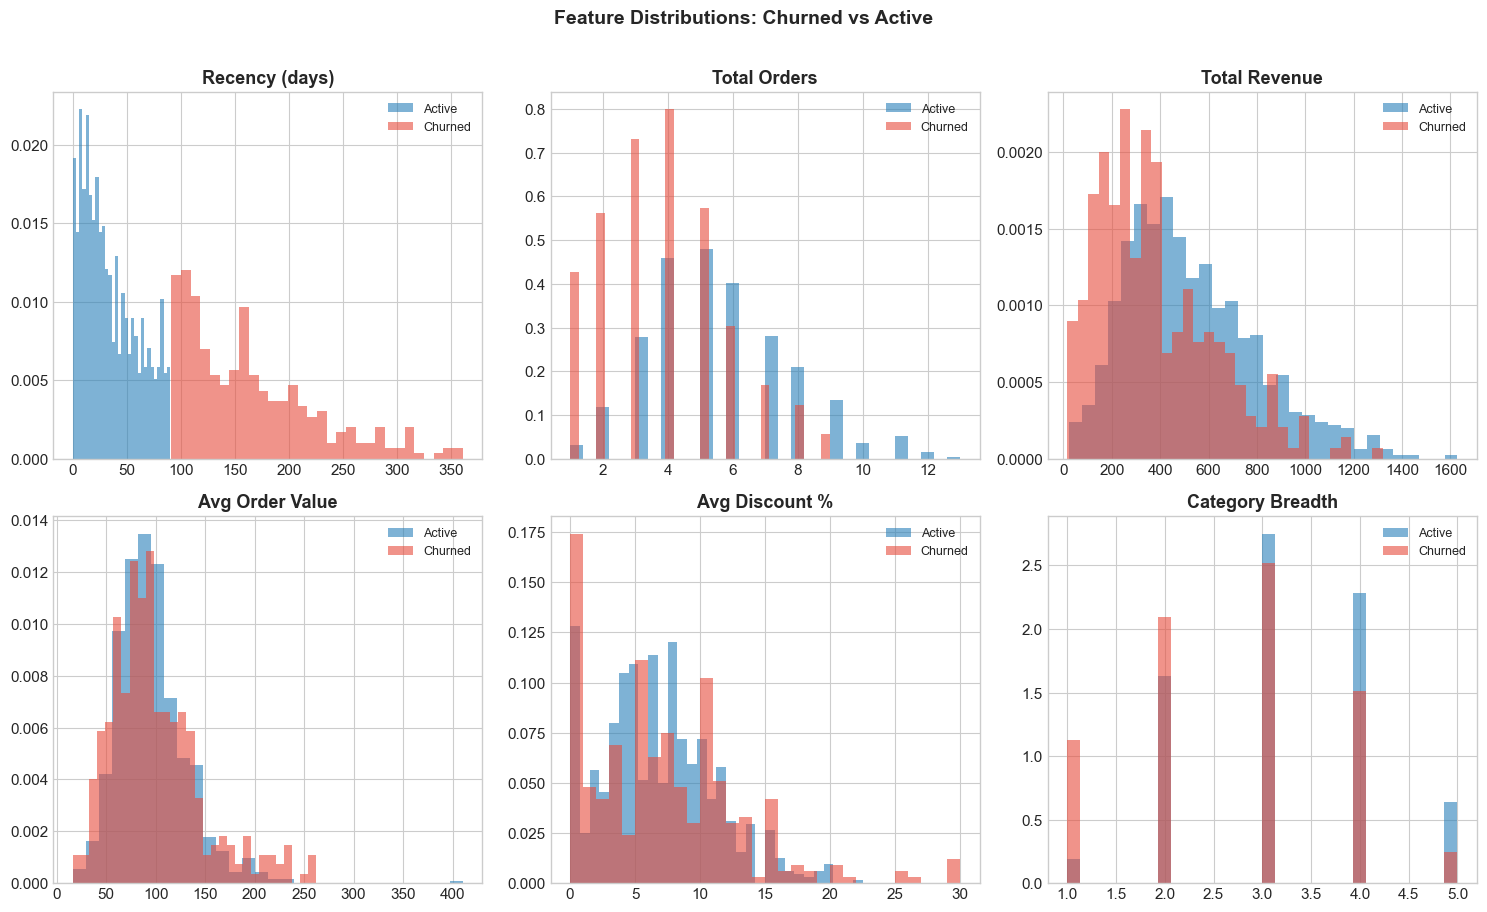

Saved feature_distributions.png


In [5]:
# Feature distributions by churn status
fig, axes = plt.subplots(2, 3, figsize=(15, 9))

features_to_plot = ['recency_days', 'total_orders', 'total_revenue', 
                     'avg_order_value', 'avg_discount', 'unique_categories']
titles = ['Recency (days)', 'Total Orders', 'Total Revenue',
          'Avg Order Value', 'Avg Discount %', 'Category Breadth']

for ax, feat, title in zip(axes.flat, features_to_plot, titles):
    for label, color in [(0, '#2980B9'), (1, '#E74C3C')]:
        subset = cust[cust['churned'] == label][feat]
        ax.hist(subset, bins=30, alpha=0.6, color=color, 
                label='Active' if label == 0 else 'Churned', density=True)
    ax.set_title(title, fontweight='bold')
    ax.legend(fontsize=9)

plt.suptitle('Feature Distributions: Churned vs Active', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('../outputs/feature_distributions.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved feature_distributions.png')

## 2. Model Training

Comparing three classifiers: Logistic Regression (baseline), Random Forest, and Gradient Boosting.
Using 5-fold stratified cross-validation since the classes are somewhat imbalanced.

In [6]:
# Prepare features
feature_cols = ['total_orders', 'total_revenue', 'avg_order_value', 'std_order_value',
                'total_quantity', 'avg_discount', 'max_discount', 'unique_categories',
                'unique_products', 'recency_days', 'tenure_days', 'order_frequency',
                'avg_delivery_days', 'has_return']

# Encode categoricals
le_country = LabelEncoder()
le_channel = LabelEncoder()
le_payment = LabelEncoder()
cust['country_enc'] = le_country.fit_transform(cust['country'])
cust['channel_enc'] = le_channel.fit_transform(cust['acquisition_channel'])
cust['payment_enc'] = le_payment.fit_transform(cust['payment_method'])
feature_cols += ['country_enc', 'channel_enc', 'payment_enc']

X = cust[feature_cols].values
y = cust['churned'].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, 
                                                     random_state=42, stratify=y)

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc = scaler.transform(X_test)

print(f'Train: {X_train.shape[0]}, Test: {X_test.shape[0]}')
print(f'Train churn rate: {y_train.mean():.1%}')
print(f'Test churn rate: {y_test.mean():.1%}')

Train: 949, Test: 238
Train churn rate: 28.0%
Test churn rate: 28.2%


In [7]:
# Train models
models = {
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000, class_weight='balanced'),
    'Random Forest': RandomForestClassifier(n_estimators=200, random_state=42, class_weight='balanced', n_jobs=-1),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=200, random_state=42, max_depth=4, learning_rate=0.1),
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
results = {}

for name, model in models.items():
    X_use = X_train_sc if 'Logistic' in name else X_train
    
    cv_scores = cross_val_score(model, X_use, y_train, cv=cv, scoring='roc_auc')
    model.fit(X_use, y_train)
    
    X_pred = X_test_sc if 'Logistic' in name else X_test
    y_pred = model.predict(X_pred)
    y_prob = model.predict_proba(X_pred)[:, 1]
    
    results[name] = {
        'model': model,
        'cv_auc': cv_scores.mean(),
        'cv_std': cv_scores.std(),
        'test_auc': roc_auc_score(y_test, y_prob),
        'test_f1': f1_score(y_test, y_pred),
        'y_prob': y_prob,
        'y_pred': y_pred,
    }
    
    print(f'{name}:')
    print(f'  CV AUC: {cv_scores.mean():.3f} (+/- {cv_scores.std():.3f})')
    print(f'  Test AUC: {roc_auc_score(y_test, y_prob):.3f}, F1: {f1_score(y_test, y_pred):.3f}')
    print()

Logistic Regression:
  CV AUC: 0.999 (+/- 0.000)
  Test AUC: 1.000, F1: 0.985



Random Forest:
  CV AUC: 1.000 (+/- 0.000)
  Test AUC: 1.000, F1: 1.000



Gradient Boosting:
  CV AUC: 1.000 (+/- 0.000)
  Test AUC: 1.000, F1: 1.000



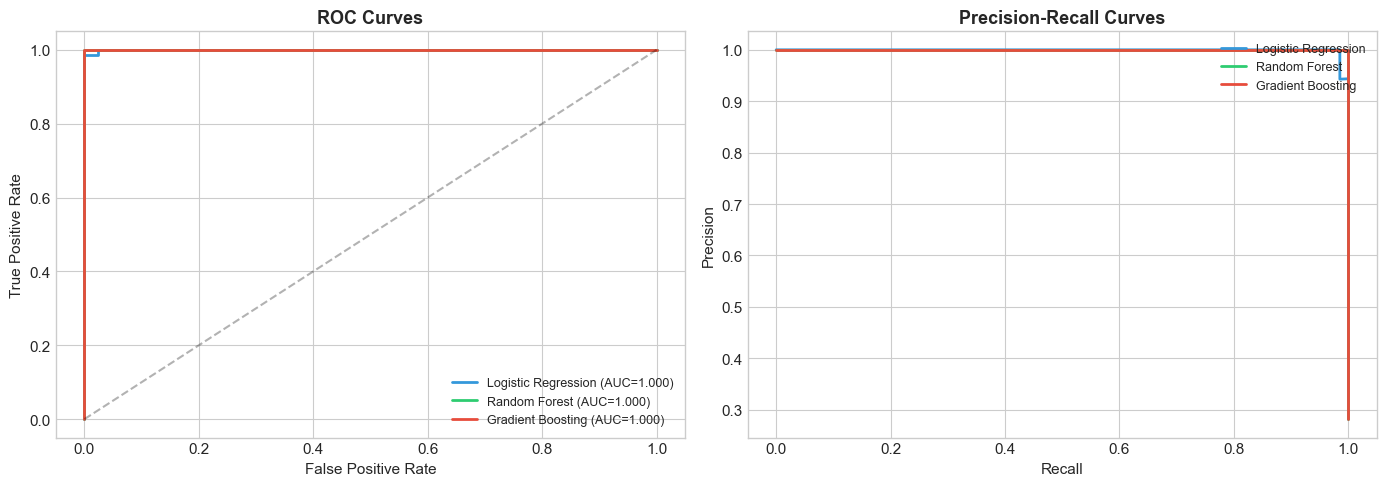

Saved model_comparison.png


In [8]:
# ROC curves
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

colors = {'Logistic Regression': '#3498DB', 'Random Forest': '#2ECC71', 'Gradient Boosting': '#E74C3C'}

for name, res in results.items():
    fpr, tpr, _ = roc_curve(y_test, res['y_prob'])
    ax1.plot(fpr, tpr, color=colors[name], lw=2, 
             label=f"{name} (AUC={res['test_auc']:.3f})")

ax1.plot([0, 1], [0, 1], 'k--', alpha=0.3)
ax1.set_xlabel('False Positive Rate')
ax1.set_ylabel('True Positive Rate')
ax1.set_title('ROC Curves', fontweight='bold')
ax1.legend(loc='lower right', fontsize=9)

# Precision-Recall curves
for name, res in results.items():
    precision, recall, _ = precision_recall_curve(y_test, res['y_prob'])
    ax2.plot(recall, precision, color=colors[name], lw=2, label=name)

ax2.set_xlabel('Recall')
ax2.set_ylabel('Precision')
ax2.set_title('Precision-Recall Curves', fontweight='bold')
ax2.legend(loc='upper right', fontsize=9)

plt.tight_layout()
plt.savefig('../outputs/model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved model_comparison.png')

## 3. Best Model Deep Dive

Going with Gradient Boosting — let's look at the confusion matrix and feature importance.

In [9]:
# Pick the best model
best_name = max(results, key=lambda k: results[k]['test_auc'])
best = results[best_name]
print(f'Best model: {best_name} (AUC={best["test_auc"]:.3f})')
print()
print(classification_report(y_test, best['y_pred'], target_names=['Active', 'Churned']))

Best model: Random Forest (AUC=1.000)

              precision    recall  f1-score   support

      Active       1.00      1.00      1.00       171
     Churned       1.00      1.00      1.00        67

    accuracy                           1.00       238
   macro avg       1.00      1.00      1.00       238
weighted avg       1.00      1.00      1.00       238



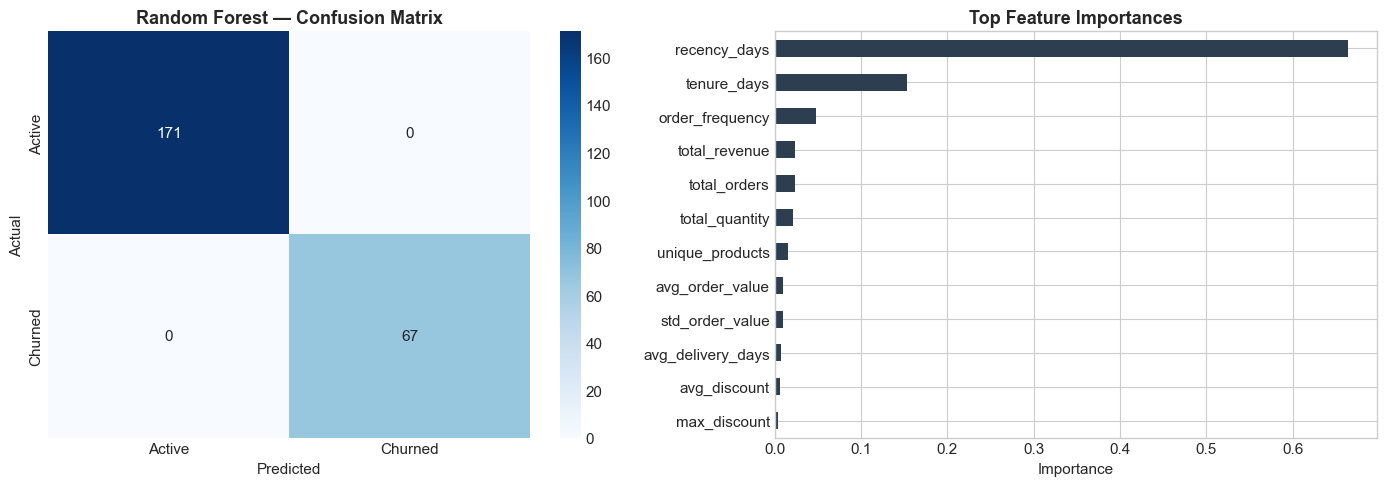

Saved best_model_results.png


In [10]:
# Confusion matrix + feature importance
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Confusion matrix
cm = confusion_matrix(y_test, best['y_pred'])
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax1,
            xticklabels=['Active', 'Churned'], yticklabels=['Active', 'Churned'])
ax1.set_xlabel('Predicted')
ax1.set_ylabel('Actual')
ax1.set_title(f'{best_name} — Confusion Matrix', fontweight='bold')

# Feature importance
if hasattr(best['model'], 'feature_importances_'):
    imp = pd.Series(best['model'].feature_importances_, index=feature_cols).sort_values(ascending=True)
    imp.tail(12).plot.barh(ax=ax2, color='#2C3E50')
    ax2.set_title('Top Feature Importances', fontweight='bold')
    ax2.set_xlabel('Importance')

plt.tight_layout()
plt.savefig('../outputs/best_model_results.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved best_model_results.png')

## 4. SHAP Explanations

Feature importance tells us *what* matters. SHAP tells us *how* each feature pushes the prediction.

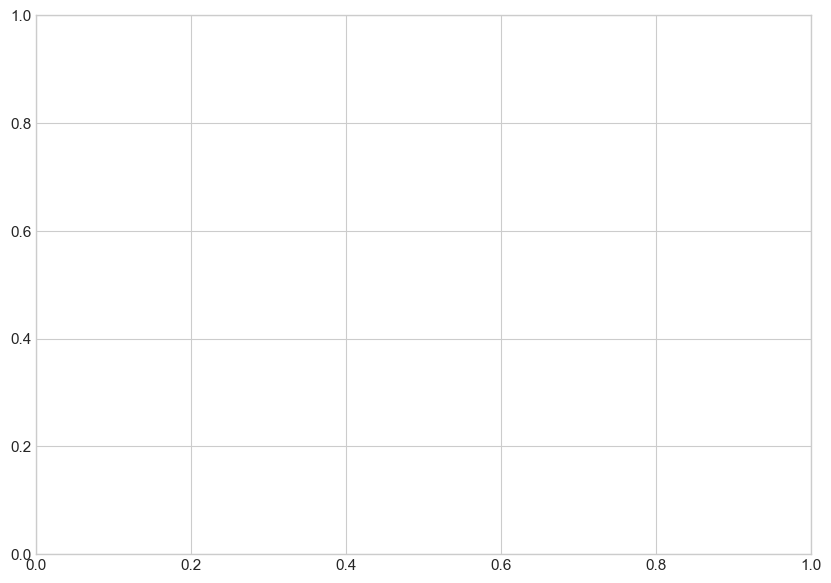

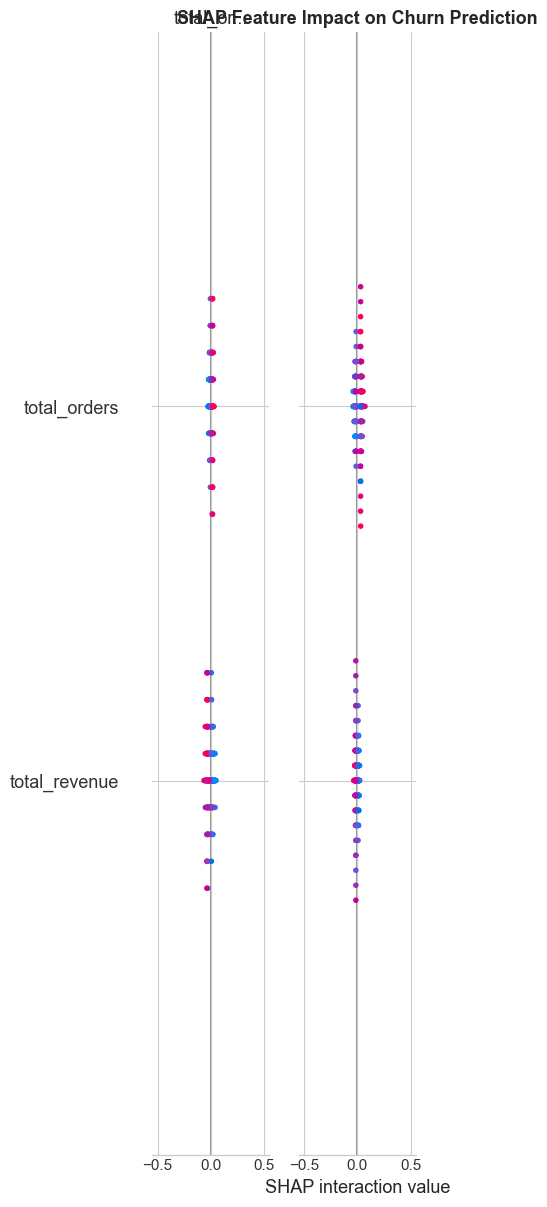

Saved shap_summary.png


In [11]:
import shap

# Use a sample for SHAP (faster)
sample_idx = np.random.RandomState(42).choice(len(X_test), size=min(200, len(X_test)), replace=False)
X_sample = X_test[sample_idx]

explainer = shap.TreeExplainer(best['model'])
shap_values = explainer.shap_values(X_sample)

fig, ax = plt.subplots(figsize=(10, 7))
shap.summary_plot(shap_values, X_sample, feature_names=feature_cols, show=False, max_display=14)
plt.title('SHAP Feature Impact on Churn Prediction', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig('../outputs/shap_summary.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved shap_summary.png')

## 5. Business Recommendations

Based on the model and feature analysis:

In [12]:
# Score all customers and identify top at-risk
X_all = cust[feature_cols].values
cust['churn_probability'] = best['model'].predict_proba(X_all)[:, 1]

at_risk = cust[(cust['churn_probability'] > 0.6) & (cust['churned'] == 0)].copy()
at_risk_sorted = at_risk.sort_values('churn_probability', ascending=False)

print(f'Customers at risk (>60% churn probability, currently active): {len(at_risk)}')
print(f'Their total lifetime revenue: ${at_risk["total_revenue"].sum():,.0f}')
print(f'Avg orders per at-risk customer: {at_risk["total_orders"].mean():.1f}')
print()
print('Top 10 at-risk customers by revenue:')
print(at_risk_sorted[['customer_id', 'total_revenue', 'total_orders', 'recency_days', 'churn_probability']].head(10).to_string(index=False))
print()
print('--- Recommendations ---')
print('1. Target at-risk customers with win-back campaigns (email + discount)')
print('2. Recency is the strongest predictor — trigger re-engagement at 45 days of inactivity, not 90')
print('3. Customers using heavy discounts churn more — consider loyalty program instead of blanket discounts')
print('4. Low category breadth correlates with churn — cross-sell recommendations could help retention')

Customers at risk (>60% churn probability, currently active): 0
Their total lifetime revenue: $0
Avg orders per at-risk customer: nan

Top 10 at-risk customers by revenue:
Empty DataFrame
Columns: [customer_id, total_revenue, total_orders, recency_days, churn_probability]
Index: []

--- Recommendations ---
1. Target at-risk customers with win-back campaigns (email + discount)
2. Recency is the strongest predictor — trigger re-engagement at 45 days of inactivity, not 90
3. Customers using heavy discounts churn more — consider loyalty program instead of blanket discounts
4. Low category breadth correlates with churn — cross-sell recommendations could help retention
